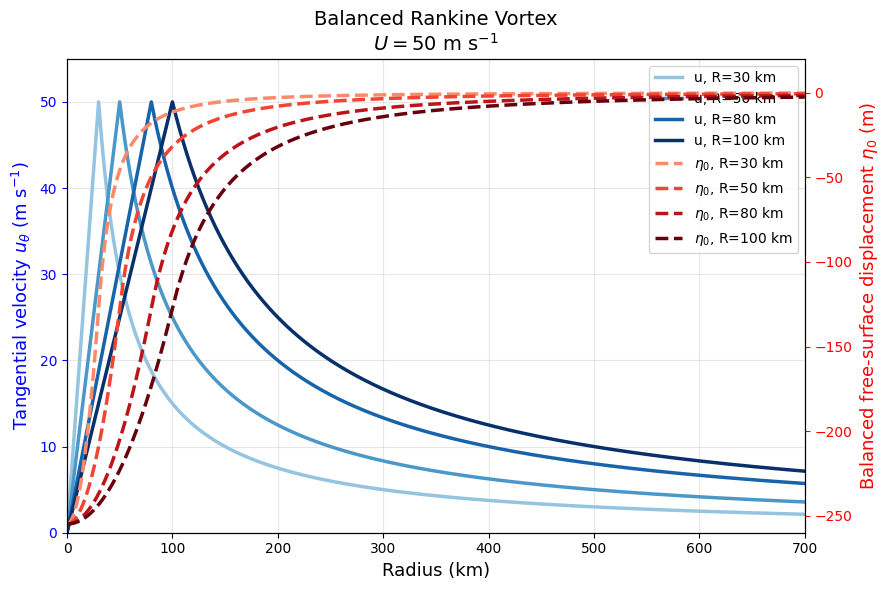

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Parameters
# ============================================================

U = 50.0          # m/s
g = 9.81          # m/s^2

R_list = [30, 50, 80, 100]    # km

# radial coordinate
r_max = 700.0     # km
dr = 0.5          # km

r_km = np.arange(0.0, r_max + dr, dr)
r = r_km * 1000.0     # meters

# ============================================================
# Figure
# ============================================================

fig, ax1 = plt.subplots(figsize=(9,6))
ax2 = ax1.twinx()

# Blue colors for velocity
blue_colors = plt.cm.Blues(np.linspace(0.4,1.0,len(R_list)))

# Red colors for eta
red_colors = plt.cm.Reds(np.linspace(0.4,1.0,len(R_list)))

# ============================================================
# Loop over vortex radii
# ============================================================

for i, R_km in enumerate(R_list):

    R = R_km * 1000.0

    # ---------------------------------------------
    # Rankine vortex
    # ---------------------------------------------
    u = np.where(
        r <= R,
        U * r / R,
        U * R / np.maximum(r,1.0)
    )

    # ---------------------------------------------
    # Balanced free surface
    # ---------------------------------------------
    eta = np.where(
        r <= R,
        -(U**2/g) * (1.0 - 0.5*(r/R)**2),
        -(U**2 * R**2)/(2.0*g*np.maximum(r,1.0)**2)
    )

    # velocity
    ax1.plot(
        r_km,
        u,
        color=blue_colors[i],
        lw=2.5,
        label=f"u, R={R_km} km"
    )

    # free surface
    ax2.plot(
        r_km,
        eta,
        color=red_colors[i],
        lw=2.5,
        ls="--",
        label=fr"$\eta_0$, R={R_km} km"
    )

# ============================================================
# Labels
# ============================================================

ax1.set_xlabel("Radius (km)", fontsize=13)

ax1.set_ylabel(
    "Tangential velocity $u_\\theta$ (m s$^{-1}$)",
    color="blue",
    fontsize=13
)

ax2.set_ylabel(
    "Balanced free-surface displacement $\\eta_0$ (m)",
    color="red",
    fontsize=13
)

ax1.tick_params(axis='y', colors='blue')
ax2.tick_params(axis='y', colors='red')

ax1.set_xlim(0, r_max)
ax1.set_ylim(0,55)
ax2.set_ylim(-260,20)
ax1.grid(True, alpha=0.3)

# ============================================================
# Combined legend
# ============================================================

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper right",
    fontsize=10
)

plt.title(
    "Balanced Rankine Vortex\n"
    r"$U=50$ m s$^{-1}$",
    fontsize=14
)

plt.tight_layout()
plt.show()


(0.0, 700.0)

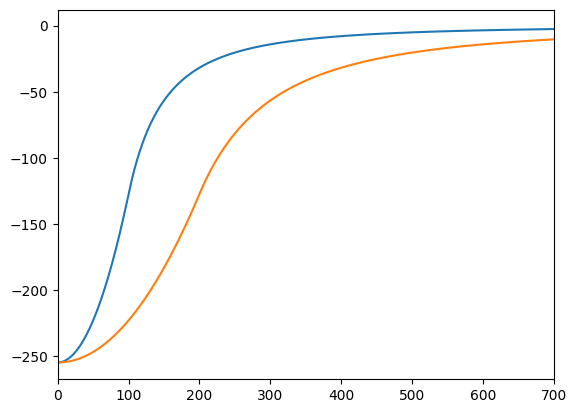

In [7]:
def get_profile_Rankine(R_km,U):
    R = R_km * 1000.0

    # ---------------------------------------------
    # Rankine vortex
    # ---------------------------------------------
    u = np.where(
        r <= R,
        U * r / R,
        U * R / np.maximum(r,1.0))

    # ---------------------------------------------
    # Balanced free surface
    # ---------------------------------------------
    eta = np.where(
        r <= R,
        -(U**2/g) * (1.0 - 0.5*(r/R)**2),
        -(U**2 * R**2)/(2.0*g*np.maximum(r,1.0)**2))

    return u,eta

u1,h1 = get_profile_Rankine(50,50)
u2,h2 = get_profile_Rankine(100,50)
plt.plot(h1)
plt.plot(h2)
plt.xlim(0,700)